In [1]:
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

plt.style.use('default')

data_path = Path('/LARGE0/gr10478/b37974/Pulmonary_Hypertension/cteph_agp3k.v6/wgs.auto.par/results/16_cov_pheno_prep')

# 1) sex + pc (pc from BBJ projection)
cov_bbj_sex_pc = pd.read_csv(data_path / 'popgmm_subset_on_bbj_pcs.cov.sex.tsv', sep='\t')

# 2) sex + pc (pc from our genotype)
cov_genotype_sex_pc = pd.read_csv(data_path / 'popgmm_relatedness_aware_projection.cov.sex.tsv', sep='\t')

# 3) sex + age + pc (pc from BBJ projection)
cov_bbj_sex_age_pc = pd.read_csv(data_path / 'popgmm_subset_on_bbj_pcs.cov.sex_age_agez.tsv', sep='\t')

# 4) sex + age + pc (pc from our genotype)
cov_genotype_sex_age_pc = pd.read_csv(data_path / 'popgmm_relatedness_aware_projection.cov.sex_age_agez.tsv', sep='\t')

# 5) phenotype
pheno = pd.read_csv(data_path / 'popgmm_subset_on_bbj_pcs.pheno.tsv', sep='\t')

In [2]:

# -- Constants and helper functions ---------------------------------------------
import warnings
from sklearn.linear_model import LogisticRegression

ID_COLS   = ['#FID', 'IID']
PHENO_COL = 'PHENO1'
SEX_COL   = 'SEX'
AGE_COL   = 'AGE_Z'
MAX_PC    = 20


def merge_cov_pheno(cov_df, pheno_df):
    """Inner-join covariate and phenotype tables on ID columns."""
    return cov_df.merge(pheno_df[ID_COLS + [PHENO_COL]], on=ID_COLS, how='inner')


def detect_and_encode_pheno(df, pheno_col):
    """Return binary 0/1 phenotype array (handles 1/2 coding and 0/1)."""
    y = df[pheno_col].values.copy()
    unique = set(y)
    if unique <= {1, 2}:
        y = (y == 2).astype(int)
    return y


def fit_model(df, feature_cols, null_cols=None):
    """Return McFadden pseudo-R² for logistic regression with given features.

    null_cols: covariates for the null model (default: sex-only baseline).
               R² measures improvement of feature_cols model over this baseline.
    """
    import numpy as _np

    if null_cols is None:
        null_cols = [SEX_COL]

    y      = detect_and_encode_pheno(df, PHENO_COL)
    X_full = df[feature_cols].values
    X_null = df[null_cols].values

    with warnings.catch_warnings():
        warnings.simplefilter('ignore')
        clf_full = LogisticRegression(C=1e12, solver='lbfgs', max_iter=1000)
        clf_full.fit(X_full, y)
        p_full  = clf_full.predict_proba(X_full)
        ll_full = _np.sum(_np.log(_np.clip(
            p_full[_np.arange(len(y)), y], 1e-15, 1)))

        clf_null = LogisticRegression(C=1e12, solver='lbfgs', max_iter=1000)
        clf_null.fit(X_null, y)
        p_null  = clf_null.predict_proba(X_null)
        ll_null = _np.sum(_np.log(_np.clip(
            p_null[_np.arange(len(y)), y], 1e-15, 1)))

    return 1.0 - ll_full / ll_null


def get_pc_cols(df):
    """Return PC columns (start with 'PC', end with '_AVG'), sorted numerically."""
    cols = [c for c in df.columns if c.startswith('PC') and c.endswith('_AVG')]
    return sorted(cols, key=lambda c: int(c[2:].replace('_AVG', '')))


def build_curve(df, base_cov, max_pc, null_cols=None):
    """
    For k = 0 .. max_pc, fit model with base_cov + first-k PCs against a
    sex-only null model (or the supplied null_cols).
    Returns DataFrame with columns: k_included, r2, step_gain.
    """
    import pandas as _pd
    if null_cols is None:
        null_cols = [SEX_COL]
    pc_cols = get_pc_cols(df)[:max_pc]
    rows = []
    prev_r2 = None
    for k in range(0, max_pc + 1):
        features = base_cov + pc_cols[:k]
        r2 = fit_model(df, features, null_cols=null_cols)
        step = (r2 - prev_r2) if prev_r2 is not None else float('nan')
        rows.append({'k_included': k, 'r2': r2, 'step_gain': step})
        prev_r2 = r2
    return _pd.DataFrame(rows)


# -- Merge dataframes -----------------------------------------------------------
merged_bbj_sex_df      = merge_cov_pheno(cov_bbj_sex_pc,      pheno)
merged_genotype_sex_df = merge_cov_pheno(cov_genotype_sex_pc, pheno)
merged_bbj_age_df      = merge_cov_pheno(cov_bbj_sex_age_pc,  pheno)
merged_genotype_age_df = merge_cov_pheno(cov_genotype_sex_age_pc, pheno)

# -- Settings dictionary --------------------------------------------------------
settings = {
    'no_age': {
        'base_cov': [SEX_COL],
        'data_map': {
            'bbj':      merged_bbj_sex_df,
            'genotype': merged_genotype_sex_df,
        },
    },
    'with_age': {
        'base_cov': [SEX_COL, AGE_COL],
        'data_map': {
            'bbj':      merged_bbj_age_df,
            'genotype': merged_genotype_age_df,
        },
    },
}

print('settings ready - merged shapes:')
for _tag, _cfg in settings.items():
    for _src, _df in _cfg['data_map'].items():
        print(f'  {_tag}/{_src}: {_df.shape}')

settings ready - merged shapes:
  no_age/bbj: (2193, 24)
  no_age/genotype: (2193, 24)
  with_age/bbj: (2131, 26)
  with_age/genotype: (2131, 26)


## Covariate Selection Framework: A Three-Dimensional Joint Optimization Problem

### Objective
This analysis is designed to identify an appropriate covariate specification for the primary GWAS model. Covariate selection is formulated as a three-dimensional joint optimization problem:
1. Whether to include clinical covariates (age and sex)
2. Which principal component set to use (BBJ-projected PCs or genotype-derived PCs)
3. How many principal components to include ($k$)

### Statistical Framework
For each covariate configuration, we fit a logistic regression model and compute McFadden's pseudo-$R^2$ as follows:
$$
R^2_{\mathrm{McFadden}} = 1 - \frac{\ell_{\mathrm{full}}}{\ell_{\mathrm{null}}}
$$
where $\ell_{\mathrm{null}}$ denotes the log-likelihood of the intercept-only model and $\ell_{\mathrm{full}}$ denotes the log-likelihood of the model including the current covariate set (age, sex, and PCs).

> Interpretation: this quantity should be understood as a likelihood-based model improvement metric for relative comparison across candidate specifications; it is not equivalent to the variance-explained $R^2$ used in linear regression.

### Three-Dimensional Comparison Space
Each curve in this notebook corresponds to a fixed setting in two dimensions and a scan across the third:
- Dimension A: whether age and sex are included
- Dimension B: which PC source is used
- Dimension C: the number of PCs included, $k = 0,1,\dots,20$

Accordingly, the comparison spans eight curves in total (four covariate baselines by two PC sources):
- PC only
- PC + Sex
- PC + Age
- PC + Age + Sex

Each baseline is evaluated separately with BBJ PCs and genotype-derived PCs.

### Decision Criteria
In addition to the cumulative fit improvement $R^2(k)$, we examine the incremental gain:
$$
\Delta R^2(k) = R^2(k) - R^2(k-1),\quad k\ge 1
$$
The decision logic is as follows:
1. For each covariate baseline, identify a candidate $k$ from the plateau behavior of $R^2(k)$ and the decay of $\Delta R^2(k)$.
2. Within the same baseline, compare the BBJ and genotype PC sources in terms of stability and final fit.
3. Around the candidate $k$, compare `PC only`, `PC+Sex`, `PC+Age`, and `PC+Age+Sex` to assess whether age and sex contribute independently and consistently.

### Interpretation and Trade-Offs
The goal is not to assign a single absolute winner from one plot, but to establish a reproducible selection strategy:
- **Inspect the curve shape first.** If $R^2(k)$ rises rapidly at small $k$ and then plateaus, the early PCs likely capture the dominant structure, while additional PCs provide diminishing returns.
- **Then inspect incremental gains.** If $\Delta R^2(k)$ remains near zero beyond a certain $k$, PCs added after that point are more likely to represent over-adjustment than useful structure.
- **Then compare PC sources.** Given the same covariate baseline, prefer the source that yields higher cumulative gain, a smoother trajectory, an earlier plateau, and better cross-scenario consistency.
- **Finally assess age and sex.** If including age or sex produces a stable upward shift across different values of $k$ and both PC sources, retain them; if the gain is weak or only appears in isolated settings, treat their inclusion more cautiously.

### Methodological Rationale
This framework balances three risks:
- **Under-adjustment**: too few PCs or omission of age/sex may leave residual population structure or known confounding unaddressed.
- **Over-adjustment**: too many PCs may absorb genuine biological signal and reduce association power.
- **Lack of robustness**: a choice that is supported only by a single data source or a single value of $k$ may not generalize well.

Accordingly, the final covariate specification should ideally satisfy the following criteria:
1. Consistent directional behavior across PC sources
2. Stability across neighboring values of $k$
3. Clear statistical gain or biological justification for including age and sex

### Reporting Recommendation
For the Methods or Supplementary Materials, report:
- The three-dimensional decision space (A: age/sex; B: PC source; C: number of PCs)
- The selection criteria (plateau behavior, marginal-gain decay, and cross-scenario stability)
- The final model specification and a sensitivity analysis across a nearby range of $k$ values (for example, $k=6$ to $k=10$)

### Conclusion Template
We jointly tuned age/sex inclusion, PC source, and the number of PCs using pseudo-$R^2$ trajectories and incremental gains, selecting a covariate specification that is statistically robust and biologically interpretable.

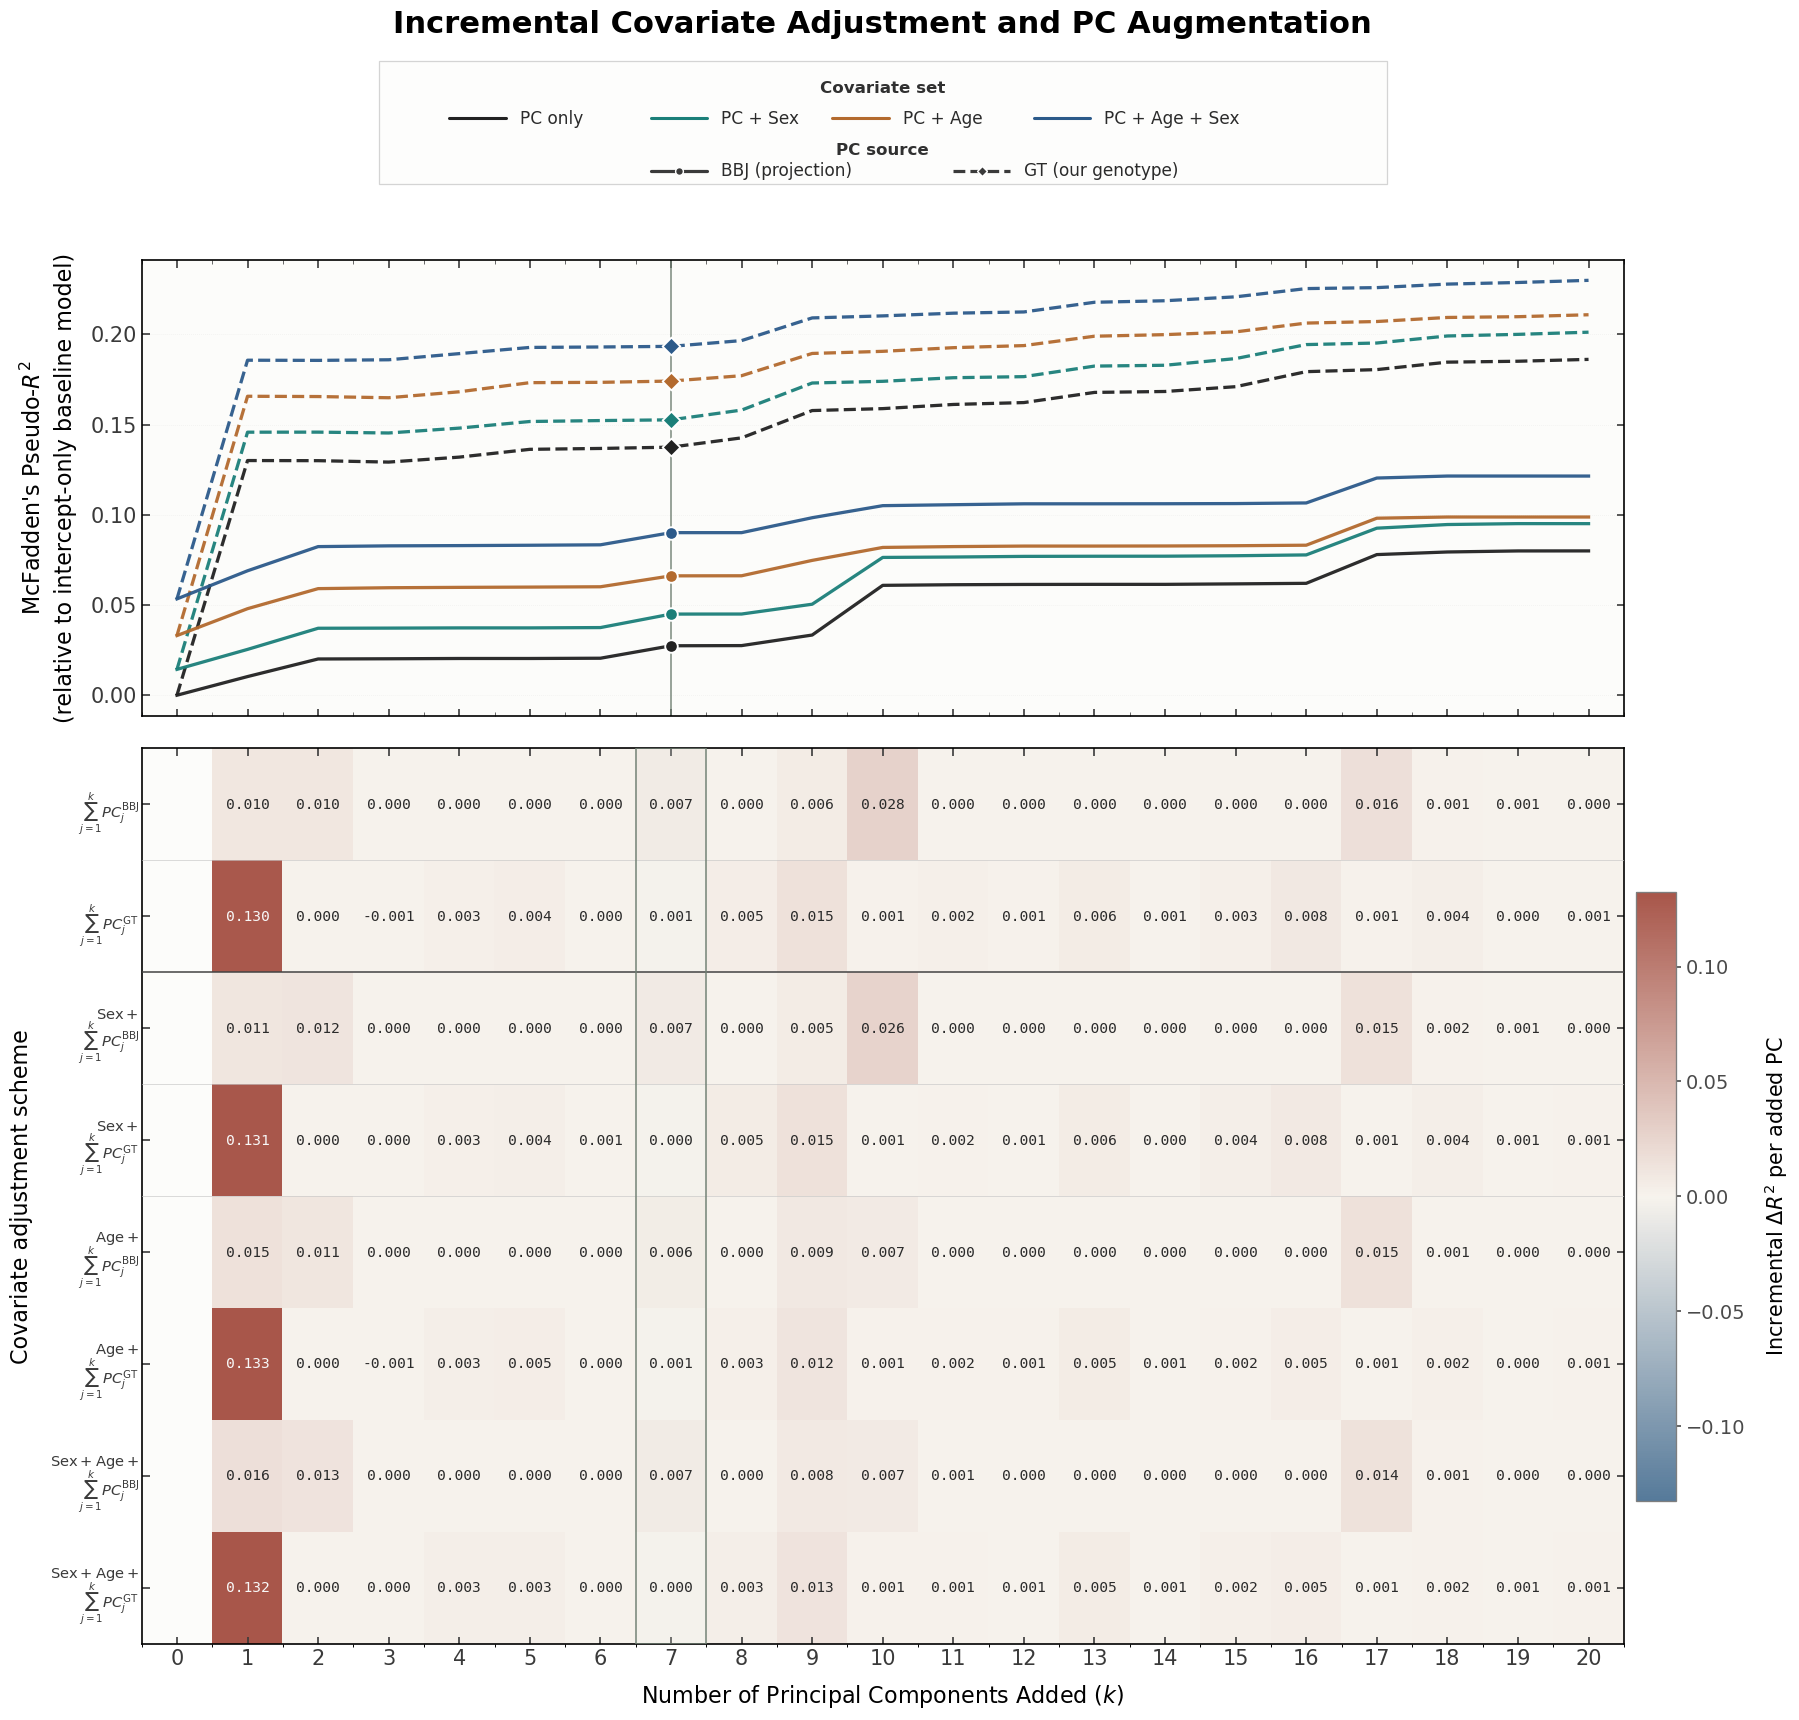

In [ ]:

# ── Incremental covariate adjustment and PC augmentation: intercept-only baseline ──
# Groups (ordered by complexity): PC / PC+Sex / PC+Age / PC+Age+Sex
# PC sources: BBJ projection (solid) vs Genotype (dashed)

import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.colors import LinearSegmentedColormap, to_rgba
from matplotlib.lines import Line2D
from matplotlib.gridspec import GridSpec
from sklearn.linear_model import LogisticRegression
from matplotlib.ticker import AutoMinorLocator

# ── Decision parameters ───────────────────────────────────────────────────────
CHOSEN_K = {
    'bbj_pc': 7,
    'genotype_pc': 7,
    'bbj_pc_sex': 7,
    'genotype_pc_sex': 7,
    'bbj_pc_age': 7,
    'genotype_pc_age': 7,
    'bbj_pc_age_sex': 7,
    'genotype_pc_age_sex': 7,
}


def _loglik_intercept_only(y):
    p = np.clip(np.mean(y), 1e-15, 1 - 1e-15)
    return np.sum(y * np.log(p) + (1 - y) * np.log(1 - p))


def fit_model_intercept_null(df, feature_cols):
    y = detect_and_encode_pheno(df, PHENO_COL)
    ll_null = _loglik_intercept_only(y)
    if len(feature_cols) == 0:
        ll_full = ll_null
    else:
        X_full = df[feature_cols].values
        with warnings.catch_warnings():
            warnings.simplefilter('ignore')
            clf = LogisticRegression(C=1e12, solver='lbfgs', max_iter=1000)
            clf.fit(X_full, y)
            p = clf.predict_proba(X_full)
            ll_full = np.sum(np.log(np.clip(p[np.arange(len(y)), y], 1e-15, 1)))
    return 1.0 - ll_full / ll_null


def build_curve_intercept_null(df, base_cov, max_pc):
    pc_cols = get_pc_cols(df)[:max_pc]
    rows, prev_r2 = [], None
    for k in range(0, max_pc + 1):
        features = base_cov + pc_cols[:k]
        r2 = fit_model_intercept_null(df, features)
        step = (r2 - prev_r2) if prev_r2 is not None else float('nan')
        rows.append({'k_included': k, 'r2': r2, 'step_gain': step})
        prev_r2 = r2
    return pd.DataFrame(rows)


def _draw_legend_item(axis, x, y, color, label, linestyle='-', marker=None, linewidth=2.2, markersize=5.8):
    """Draw a compact custom legend entry inside the unified legend panel."""
    x0 = x - 0.070
    x1 = x - 0.014
    axis.plot(
        [x0, x1], [y, y],
        color=color, linestyle=linestyle, linewidth=linewidth,
        solid_capstyle='round', transform=axis.transAxes, clip_on=False,
    )
    if marker is not None:
        axis.plot(
            [(x0 + x1) / 2], [y],
            marker=marker, markersize=markersize,
            markerfacecolor=color, markeredgecolor='white', markeredgewidth=1.0,
            linestyle='None', transform=axis.transAxes, clip_on=False,
        )
    axis.text(
        x, y, label,
        transform=axis.transAxes,
        va='center', ha='left', color='#2B2B2B', fontsize=_FS['legend'],
    )


# ── Build all 8 curves (ordered: PC / PC+Sex / PC+Age / PC+Age+Sex) ─────────
_curves = {
    'bbj_pc':              build_curve_intercept_null(merged_bbj_sex_df,      [],                 MAX_PC),
    'genotype_pc':         build_curve_intercept_null(merged_genotype_sex_df, [],                 MAX_PC),
    'bbj_pc_sex':          build_curve_intercept_null(merged_bbj_sex_df,      [SEX_COL],          MAX_PC),
    'genotype_pc_sex':     build_curve_intercept_null(merged_genotype_sex_df, [SEX_COL],          MAX_PC),
    'bbj_pc_age':          build_curve_intercept_null(merged_bbj_age_df,      [AGE_COL],          MAX_PC),
    'genotype_pc_age':     build_curve_intercept_null(merged_genotype_age_df, [AGE_COL],          MAX_PC),
    'bbj_pc_age_sex':      build_curve_intercept_null(merged_bbj_age_df,      [AGE_COL, SEX_COL], MAX_PC),
    'genotype_pc_age_sex': build_curve_intercept_null(merged_genotype_age_df, [AGE_COL, SEX_COL], MAX_PC),
}

_ROW_ORDER = [
    'bbj_pc', 'genotype_pc',
    'bbj_pc_sex', 'genotype_pc_sex',
    'bbj_pc_age', 'genotype_pc_age',
    'bbj_pc_age_sex', 'genotype_pc_age_sex',
]

_missing_k = [key for key in _ROW_ORDER if key not in CHOSEN_K]
_extra_k = sorted(set(CHOSEN_K) - set(_ROW_ORDER))
if _missing_k or _extra_k:
    raise ValueError(f'CHOSEN_K keys mismatch; missing={_missing_k}, extra={_extra_k}')
for _key, _value in CHOSEN_K.items():
    if not isinstance(_value, (int, np.integer)):
        raise TypeError(f'CHOSEN_K[{_key!r}] must be an integer, got {type(_value).__name__}')
    if _value < 0 or _value > MAX_PC:
        raise ValueError(f'CHOSEN_K[{_key!r}] must be between 0 and {MAX_PC}, got {_value}')

_GROUP_OF = {
    'bbj_pc': 'pc',               'genotype_pc': 'pc',
    'bbj_pc_sex': 'pc_sex',       'genotype_pc_sex': 'pc_sex',
    'bbj_pc_age': 'pc_age',       'genotype_pc_age': 'pc_age',
    'bbj_pc_age_sex': 'pc_age_sex', 'genotype_pc_age_sex': 'pc_age_sex',
}

# Muted publication-style palette: lower saturation, stronger tonal separation,
# and more restrained chroma than the previous high-contrast version.
_GROUP_COLORS = {
    'pc':         '#222222',
    'pc_sex':     '#1B7F79',
    'pc_age':     '#B36A2E',
    'pc_age_sex': '#2C5A8A',
}
_GROUP_LABELS = {
    'pc':         'PC only',
    'pc_sex':     'PC + Sex',
    'pc_age':     'PC + Age',
    'pc_age_sex': 'PC + Age + Sex',
}
_COLORS = {key: _GROUP_COLORS[_GROUP_OF[key]] for key in _ROW_ORDER}
_LSTYLE = {
    'bbj_pc': '-',          'genotype_pc': '--',
    'bbj_pc_sex': '-',      'genotype_pc_sex': '--',
    'bbj_pc_age': '-',      'genotype_pc_age': '--',
    'bbj_pc_age_sex': '-',  'genotype_pc_age_sex': '--',
}
_MARKERS = {
    'bbj_pc': 'o',              'genotype_pc': 'D',
    'bbj_pc_sex': 'o',          'genotype_pc_sex': 'D',
    'bbj_pc_age': 'o',          'genotype_pc_age': 'D',
    'bbj_pc_age_sex': 'o',      'genotype_pc_age_sex': 'D',
}
_HEAT_LABELS = {
    'bbj_pc':              r'$\sum_{j=1}^{k} PC^{\mathrm{BBJ}}_{j}$',
    'genotype_pc':         r'$\sum_{j=1}^{k} PC^{\mathrm{GT}}_{j}$',
    'bbj_pc_sex':          '$\\mathrm{Sex} +$\n$\\sum_{j=1}^{k} PC^{\\mathrm{BBJ}}_{j}$',
    'genotype_pc_sex':     '$\\mathrm{Sex} +$\n$\\sum_{j=1}^{k} PC^{\\mathrm{GT}}_{j}$',
    'bbj_pc_age':          '$\\mathrm{Age} +$\n$\\sum_{j=1}^{k} PC^{\\mathrm{BBJ}}_{j}$',
    'genotype_pc_age':     '$\\mathrm{Age} +$\n$\\sum_{j=1}^{k} PC^{\\mathrm{GT}}_{j}$',
    'bbj_pc_age_sex':      '$\\mathrm{Sex} + \\mathrm{Age} +$\n$\\sum_{j=1}^{k} PC^{\\mathrm{BBJ}}_{j}$',
    'genotype_pc_age_sex': '$\\mathrm{Sex} + \\mathrm{Age} +$\n$\\sum_{j=1}^{k} PC^{\\mathrm{GT}}_{j}$',
}

# Muted diverging palette for the heatmap: deep desaturated blue -> warm off-white
# -> muted brick red. This reduces visual noise around near-zero values.
_MUTED_DIVERGING = LinearSegmentedColormap.from_list(
    'muted_diverging',
    ['#567A9A', '#F7F3ED', '#A8564A'],
    N=256,
)

_SELECTED_KS = sorted(set(CHOSEN_K.values()))
_SHARED_SELECTED_K = _SELECTED_KS[0] if len(_SELECTED_KS) == 1 else None
_SELECTION_MODE = 'shared-column' if _SHARED_SELECTED_K is not None and _SHARED_SELECTED_K >= 1 else 'per-row'
_SELECTION_COLOR = '#6F7F72'
_SELECTION_FILL = '#EEF2EC'

# ── Typography ───────────────────────────────────────────────────────────────
_FS = {
    'title': 22,
    'label': 16,
    'tick': 15,
    'legend': 12.2,
    'legend_title': 12.0,
    'heat': 10.5,
    'ytick_heat': 10.6,
    'panel': 15,
}
plt.rcParams.update({
    'font.family':        'DejaVu Sans',
    'font.size':          _FS['tick'],
    'axes.titlesize':     _FS['panel'],
    'axes.labelsize':     _FS['label'],
    'xtick.labelsize':    _FS['tick'],
    'ytick.labelsize':    _FS['tick'],
    'legend.fontsize':    _FS['legend'],
    'axes.linewidth':     1.20,
    'xtick.major.width':  1.20,
    'ytick.major.width':  1.20,
    'xtick.minor.width':  0.70,
    'ytick.minor.width':  0.70,
})

# ── Figure layout via GridSpec ────────────────────────────────────────────────
fig = plt.figure(figsize=(19.3, 18.1), facecolor='white')
gs = GridSpec(
    2, 2,
    figure=fig,
    height_ratios=[1.62, 3.18],
    width_ratios=[1, 0.027],
    hspace=0.048,
    wspace=0.016,
    top=0.84, left=0.18, right=0.975, bottom=0.075,
)
ax1 = fig.add_subplot(gs[0, 0])
ax3 = fig.add_subplot(gs[1, 0], sharex=ax1)
cax = fig.add_subplot(gs[1, 1])

for _ax in (ax1, ax3):
    _ax.set_facecolor('#FCFCFA')

# ── Upper panel: Cumulative pseudo-R² ────────────────────────────────────────
if _SELECTION_MODE == 'shared-column':
    ax1.axvline(_SHARED_SELECTED_K, color=_SELECTION_COLOR, linewidth=1.15, alpha=0.88, zorder=1)

_rk_vals = {}
for _key in _ROW_ORDER:
    _g = _curves[_key].sort_values('k_included')
    ax1.plot(
        _g['k_included'], _g['r2'],
        color=_COLORS[_key], linestyle=_LSTYLE[_key],
        linewidth=2.35, alpha=0.95,
    )
    _rk_vals[_key] = float(_g.loc[_g['k_included'] == CHOSEN_K[_key], 'r2'].iloc[0])
    ax1.scatter(
        CHOSEN_K[_key], _rk_vals[_key],
        color=_COLORS[_key], s=82, marker=_MARKERS[_key],
        zorder=7, edgecolors='white', linewidths=1.35,
    )

ax1.set_ylabel(
    "McFadden's Pseudo-$R^{2}$\n(relative to intercept-only baseline model)",
    labelpad=10, linespacing=1.45, fontsize=_FS['label'],
)
ax1.set_axisbelow(True)
ax1.grid(axis='y', alpha=0.16, linewidth=0.55, linestyle=':', color='#A9A9A9')
ax1.xaxis.set_minor_locator(AutoMinorLocator(2))
ax1.tick_params(direction='in', length=5.4, width=1.2, top=True, right=True, which='major', colors='#3A3A3A')
ax1.tick_params(direction='in', length=2.8, width=0.7, top=True, right=True, which='minor', colors='#666666')
ax1.set_xlim(-0.5, MAX_PC + 0.5)
plt.setp(ax1.get_xticklabels(), visible=False)

# ── Lower panel: Marginal gain heatmap ───────────────────────────────────────
_mat, _rl = [], []
for _key in _ROW_ORDER:
    _step = (
        _curves[_key].set_index('k_included')['step_gain']
        .reindex(range(1, MAX_PC + 1)).fillna(0).values
    )
    _mat.append(_step)
    _rl.append(_HEAT_LABELS[_key])

_mat = np.array(_mat)
_vabs = float(np.nanmax(np.abs(_mat)))
_im = ax3.imshow(
    _mat,
    aspect='auto',
    cmap=_MUTED_DIVERGING,
    interpolation='nearest',
    vmin=-_vabs,
    vmax=_vabs,
    extent=[0.5, MAX_PC + 0.5, len(_ROW_ORDER) - 0.5, -0.5],
)

if _SELECTION_MODE == 'shared-column':
    ax3.axvspan(
        _SHARED_SELECTED_K - 0.5, _SHARED_SELECTED_K + 0.5,
        color=_SELECTION_FILL, alpha=0.18, zorder=2, lw=0,
    )

for _ri in range(_mat.shape[0]):
    for _ci in range(_mat.shape[1]):
        _v = _mat[_ri, _ci]
        _txt_col = '#F8F8F8' if abs(_v) > 0.46 * _vabs else '#2B2B2B'
        _v_disp = float(np.round(_v, 3)) + 0.0
        ax3.text(
            _ci + 1, _ri, f'{_v_disp:.3f}',
            ha='center', va='center',
            fontsize=_FS['heat'], color=_txt_col,
            fontfamily='monospace', zorder=4,
        )

for _sep in [1.5]:
    ax3.axhline(_sep, color='#444444', linewidth=1.35, zorder=3, alpha=0.82)
for _sep in [0.5, 2.5, 3.5]:
    ax3.axhline(_sep, color='#C7C7C7', linewidth=0.55, zorder=3, alpha=0.82)

if _SELECTION_MODE == 'shared-column':
    ax3.add_patch(mpatches.Rectangle(
        (_SHARED_SELECTED_K - 0.5, -0.5),
        1.0,
        len(_ROW_ORDER),
        linewidth=1.15,
        edgecolor=_SELECTION_COLOR,
        facecolor='none',
        zorder=5,
        alpha=0.92,
    ))
else:
    for _ri, _key in enumerate(_ROW_ORDER):
        _k = CHOSEN_K[_key]
        if _k < 1:
            continue
        _edge = _COLORS[_key]
        _fill = to_rgba(_edge, alpha=0.10)
        ax3.add_patch(mpatches.Rectangle(
            (_k - 0.5, _ri - 0.5),
            1.0,
            1.0,
            linewidth=1.45,
            edgecolor=_edge,
            facecolor=_fill,
            zorder=5,
        ))

ax3.set_xlabel('Number of Principal Components Added ($k$)', labelpad=10, fontsize=_FS['label'])
ax3.set_ylabel('Covariate adjustment scheme', labelpad=12, fontsize=_FS['label'])
ax3.set_yticks(range(len(_ROW_ORDER)))
_ytl = ax3.set_yticklabels(_rl, fontsize=_FS['ytick_heat'])
for _i, _key in enumerate(_ROW_ORDER):
    _ytl[_i].set_color(_COLORS[_key])
    _ytl[_i].set_fontweight('bold')
    _ytl[_i].set_linespacing(0.92)

ax3.tick_params(axis='y', pad=2, direction='in', length=5.4, width=1.2, top=True, right=True, colors='#3A3A3A')
ax3.tick_params(axis='x', direction='in', length=5.4, width=1.2, top=True, right=True, colors='#3A3A3A')
ax3.set_xlim(-0.5, MAX_PC + 0.5)
ax3.set_xticks(np.arange(0, MAX_PC + 1, 1))

# ── Colorbar: visually shorter and centred within its own column ─────────────
_cax_box = cax.get_position()
cax.set_position([
    _cax_box.x0,
    _cax_box.y0 + 0.16 * _cax_box.height,
    _cax_box.width,
    0.68 * _cax_box.height,
])
_cbar = fig.colorbar(_im, cax=cax)
_cbar.set_label(
    r'Incremental $\Delta R^{2}$ per added PC',
    rotation=90, labelpad=12, fontsize=_FS['label'] - 1,
)
_cbar.ax.axhline(0.5, color='black', linewidth=0.9, alpha=0.38)
for _sp in _cbar.ax.spines.values():
    _sp.set_linewidth(0.95)
    _sp.set_edgecolor('#7E7E7E')
_cbar.ax.tick_params(labelsize=_FS['tick'] - 1, colors='#4A4A4A')

# ── Finalize layout, then place title & a unified legend panel ───────────────
fig.canvas.draw()
_ax1_pos = ax1.get_position()
_cx = _ax1_pos.x0 + _ax1_pos.width / 2

fig.suptitle(
    'Incremental Covariate Adjustment and PC Augmentation',
    x=_cx, y=0.978, fontsize=_FS['title'], fontweight='bold',
)

# One unified legend panel reduces top clutter while preserving the two-level
# semantics: covariate colors and PC-source line/marker encoding.
_legend_w = 0.68 * _ax1_pos.width
_legend_h = 0.068
_legend_x0 = _cx - _legend_w / 2
_legend_y0 = 0.882
legend_ax = fig.add_axes((_legend_x0, _legend_y0, _legend_w, _legend_h))
legend_ax.set_xlim(0, 1)
legend_ax.set_ylim(0, 1)
legend_ax.axis('off')
legend_ax.add_patch(mpatches.Rectangle(
    (0, 0), 1, 1,
    linewidth=0.9, edgecolor='#D4D4D4', facecolor='#FDFDFC',
    transform=legend_ax.transAxes, clip_on=False,
))

legend_ax.text(
    0.5, 0.77, 'Covariate set',
    transform=legend_ax.transAxes,
    ha='center', va='center', fontsize=_FS['legend_title'],
    color='#303030', fontweight='semibold',
)
_draw_legend_item(legend_ax, 0.14, 0.53, _GROUP_COLORS['pc'], _GROUP_LABELS['pc'])
_draw_legend_item(legend_ax, 0.34, 0.53, _GROUP_COLORS['pc_sex'], _GROUP_LABELS['pc_sex'])
_draw_legend_item(legend_ax, 0.52, 0.53, _GROUP_COLORS['pc_age'], _GROUP_LABELS['pc_age'])
_draw_legend_item(legend_ax, 0.72, 0.53, _GROUP_COLORS['pc_age_sex'], _GROUP_LABELS['pc_age_sex'])

legend_ax.text(
    0.5, 0.27, 'PC source',
    transform=legend_ax.transAxes,
    ha='center', va='center', fontsize=_FS['legend_title'],
    color='#303030', fontweight='semibold',
)
_draw_legend_item(legend_ax, 0.34, 0.10, '#3A3A3A', 'BBJ (projection)', linestyle='-', marker='o', linewidth=2.3, markersize=5.6)
_draw_legend_item(legend_ax, 0.64, 0.10, '#3A3A3A', 'GT (our genotype)', linestyle='--', marker='D', linewidth=2.3, markersize=5.4)

plt.show()
# fig.savefig('pc_selection_combined_intercept_null.pdf', dpi=300, bbox_inches='tight')


## Quantitative Summary for Reporting

The following code cell generates a compact reporting table for each curve at the selected $k$ value, including the cumulative pseudo-$R^2$, the corresponding incremental gain, and the average post-selection incremental gain. This summary is intended to support manuscript writing, sensitivity assessment, and reproducible model selection.

In [ ]:
# Quantitative summary table for reporting
summary_rows = []
for key in _ROW_ORDER:
    df = _curves[key].sort_values('k_included').reset_index(drop=True)
    k_star = int(CHOSEN_K[key])

    r2_k = float(df.loc[df['k_included'] == k_star, 'r2'].iloc[0])

    if k_star >= 1:
        delta_k = float(df.loc[df['k_included'] == k_star, 'step_gain'].iloc[0])
    else:
        delta_k = np.nan

    tail = df.loc[df['k_included'] > k_star, 'step_gain'].dropna()
    tail_mean = float(tail.mean()) if len(tail) > 0 else np.nan

    source = 'BBJ' if key.startswith('bbj_') else 'GT'
    cov_label = key.replace('bbj_', '').replace('genotype_', '').replace('_', ' + ')
    cov_label = cov_label.replace('pc', 'PC').replace('age', 'Age').replace('sex', 'Sex')

    summary_rows.append({
        'model_key': key,
        'covariate_set': cov_label,
        'pc_source': source,
        'k_star': k_star,
        'R2_at_k_star': r2_k,
        'delta_R2_at_k_star': delta_k,
        'mean_delta_after_k_star': tail_mean,
    })

summary_df = pd.DataFrame(summary_rows)
summary_df = summary_df.sort_values(['covariate_set', 'pc_source']).reset_index(drop=True)

with pd.option_context('display.max_rows', None, 'display.precision', 4):
    print('Summary at selected k (for methods/results reporting):')
    display(summary_df)

# Optional compact contrasts: GT minus BBJ under matched covariate set
contrast_rows = []
for cov in summary_df['covariate_set'].unique():
    sub = summary_df[summary_df['covariate_set'] == cov]
    if set(sub['pc_source']) == {'BBJ', 'GT'}:
        r_gt = float(sub.loc[sub['pc_source'] == 'GT', 'R2_at_k_star'].iloc[0])
        r_bbj = float(sub.loc[sub['pc_source'] == 'BBJ', 'R2_at_k_star'].iloc[0])
        contrast_rows.append({
            'covariate_set': cov,
            'GT_minus_BBJ_at_k_star': r_gt - r_bbj,
        })

contrast_df = pd.DataFrame(contrast_rows).sort_values('covariate_set')
with pd.option_context('display.max_rows', None, 'display.precision', 4):
    print('PC-source contrast at selected k (GT - BBJ):')
    display(contrast_df)

Summary at selected k (for methods/results reporting):


,model_key,covariate_set,pc_source,k_star,R2_at_k_star,delta_R2_at_k_star,mean_delta_after_k_star
0,bbj_pc,PC,BBJ,7,0.0274,0.0069,0.0040
1,genotype_pc,PC,GT,7,0.1375,0.0007,0.0037
2,bbj_pc_age,PC + Age,BBJ,7,0.0661,0.0061,0.0025
3,genotype_pc_age,PC + Age,GT,7,0.1741,0.0007,0.0028
4,bbj_pc_age_sex,PC + Age + Sex,BBJ,7,0.0901,0.0067,0.0024
5,genotype_pc_age_sex,PC + Age + Sex,GT,7,0.1933,0.0003,0.0028
6,bbj_pc_sex,PC + Sex,BBJ,7,0.0450,0.0075,0.0039
7,genotype_pc_sex,PC + Sex,GT,7,0.1526,0.0004,0.0037


PC-source contrast at selected k (GT - BBJ):


,covariate_set,GT_minus_BBJ_at_k_star
0,PC,0.1101
1,PC + Age,0.1079
2,PC + Age + Sex,0.1032
3,PC + Sex,0.1076


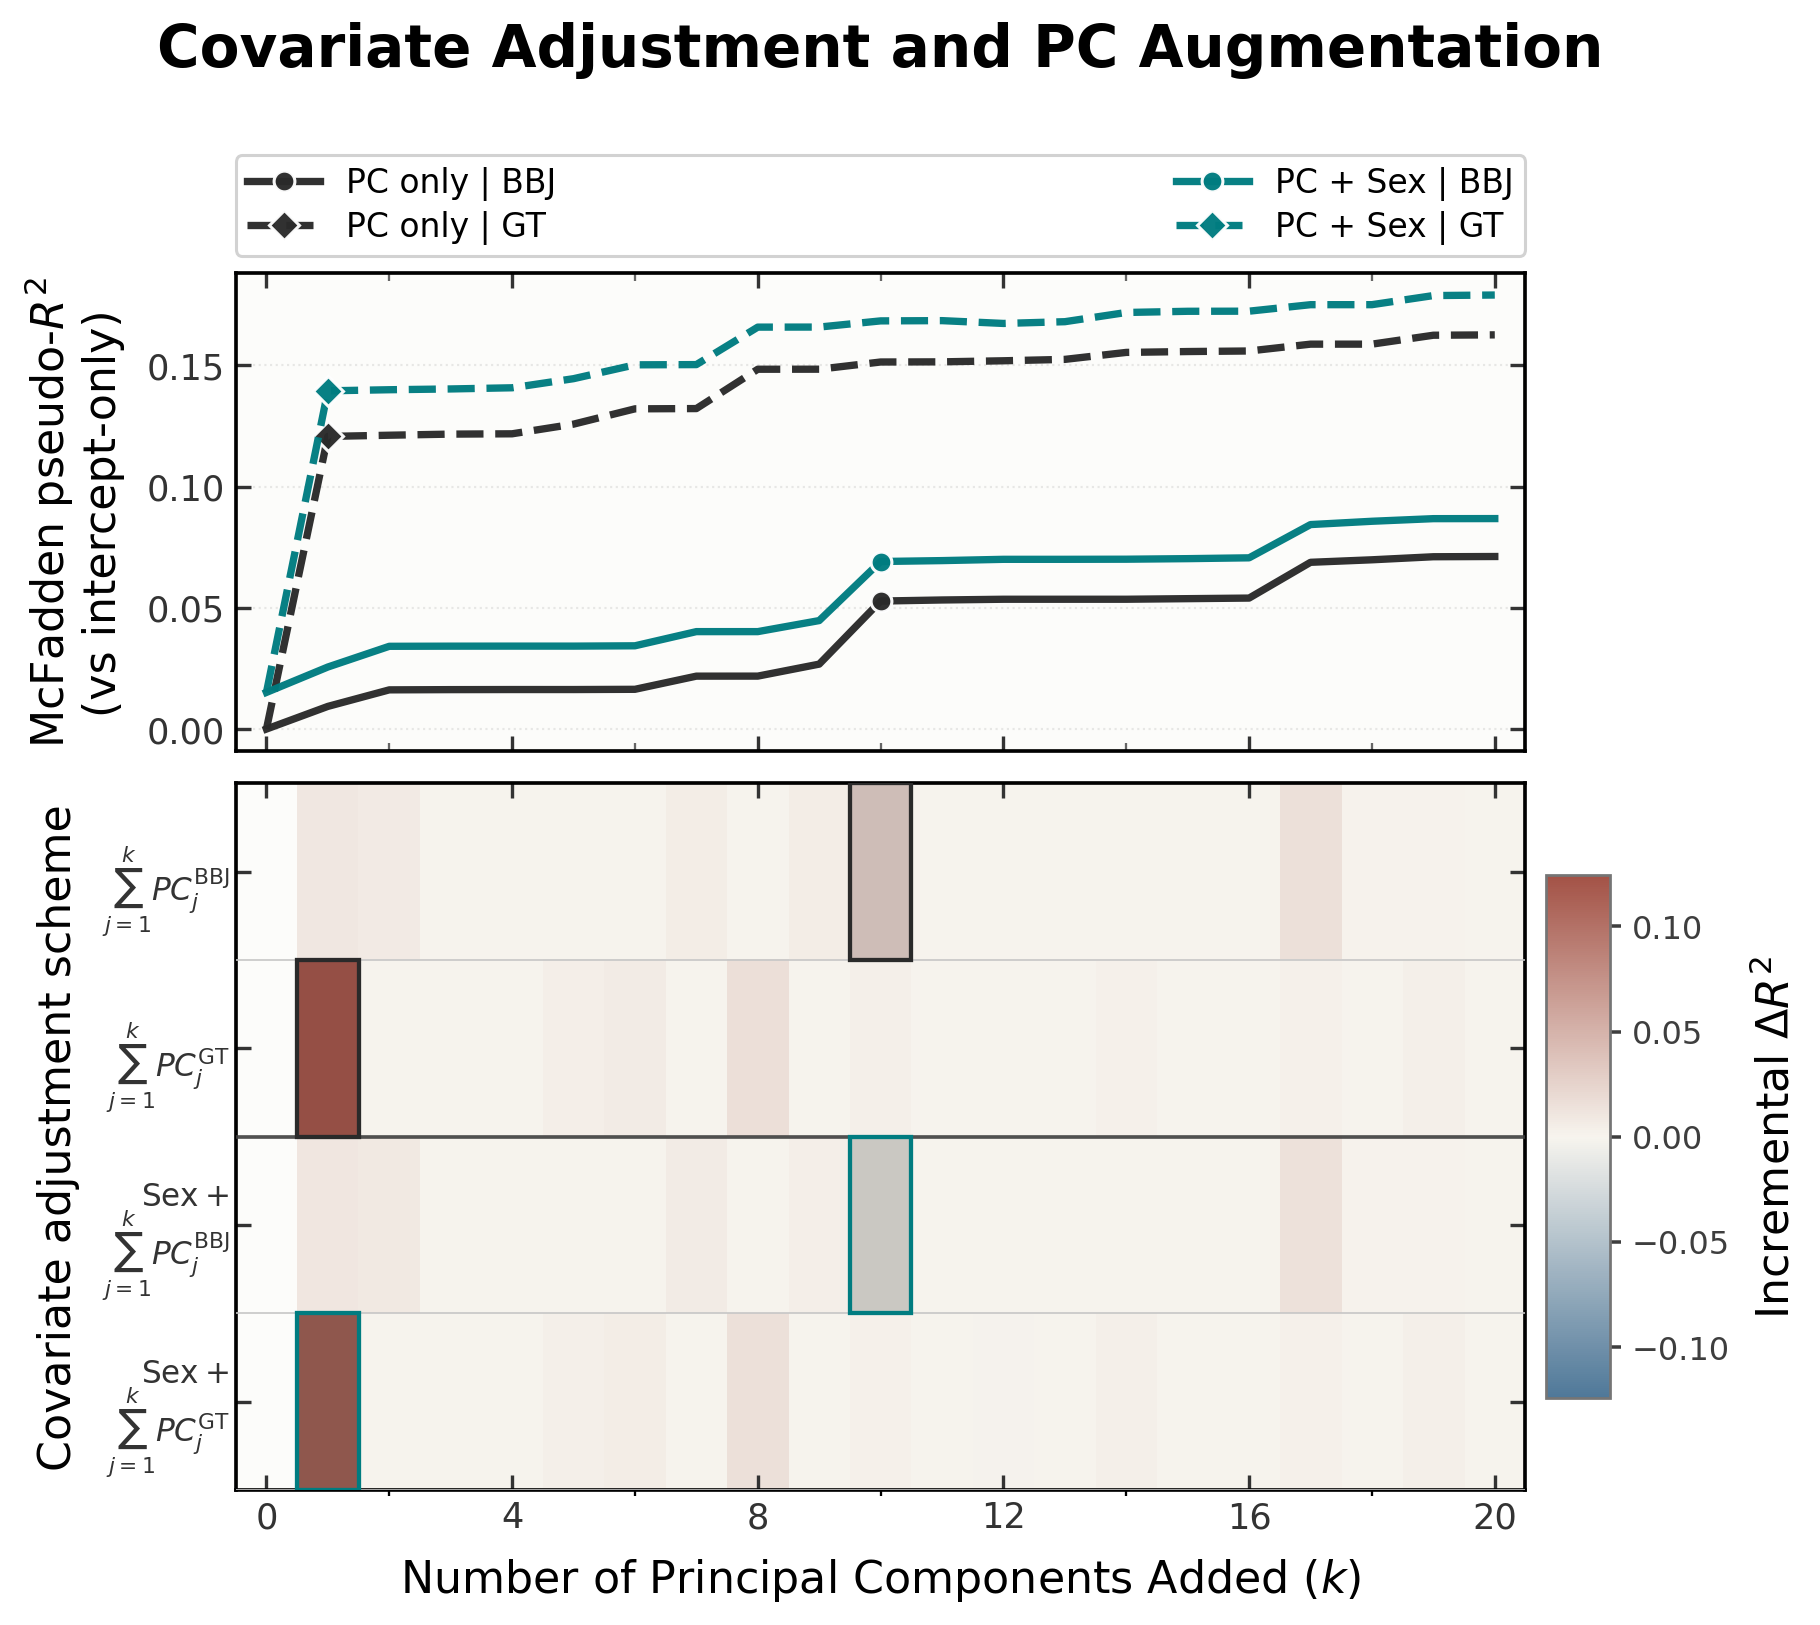

In [13]:
# ── PPT-side optimized visualization: PC only vs PC + Sex ─────────────────────
# Optimized for placing on the LEFT side of a slide, with explanation text on RIGHT.

import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.colors import LinearSegmentedColormap, to_rgba
from matplotlib.gridspec import GridSpec
from matplotlib.ticker import AutoMinorLocator
from sklearn.linear_model import LogisticRegression

# ── Decision parameters ───────────────────────────────────────────────────────
CHOSEN_K = {
    'bbj_pc': 10,
    'genotype_pc': 1,
    'bbj_pc_sex': 10,
    'genotype_pc_sex': 1,
}

# Layout mode for one-side slide placement.
PPT_SIDE_MODE = True
SHOW_HEAT_VALUES = False if PPT_SIDE_MODE else True


def _loglik_intercept_only(y):
    p = np.clip(np.mean(y), 1e-15, 1 - 1e-15)
    return np.sum(y * np.log(p) + (1 - y) * np.log(1 - p))


def fit_model_intercept_null(df, feature_cols):
    y = detect_and_encode_pheno(df, PHENO_COL)
    ll_null = _loglik_intercept_only(y)
    if len(feature_cols) == 0:
        ll_full = ll_null
    else:
        X_full = df[feature_cols].values
        with warnings.catch_warnings():
            warnings.simplefilter('ignore')
            clf = LogisticRegression(C=1e12, solver='lbfgs', max_iter=1000)
            clf.fit(X_full, y)
            p = clf.predict_proba(X_full)
            ll_full = np.sum(np.log(np.clip(p[np.arange(len(y)), y], 1e-15, 1)))
    return 1.0 - ll_full / ll_null


def build_curve_intercept_null(df, base_cov, max_pc):
    pc_cols = get_pc_cols(df)[:max_pc]
    rows, prev_r2 = [], None
    for k in range(0, max_pc + 1):
        features = base_cov + pc_cols[:k]
        r2 = fit_model_intercept_null(df, features)
        step = (r2 - prev_r2) if prev_r2 is not None else float('nan')
        rows.append({'k_included': k, 'r2': r2, 'step_gain': step})
        prev_r2 = r2
    return pd.DataFrame(rows)


# ── Build the four curves of interest ─────────────────────────────────────────
_curves = {
    'bbj_pc':          build_curve_intercept_null(merged_bbj_sex_df,      [],        MAX_PC),
    'genotype_pc':     build_curve_intercept_null(merged_genotype_sex_df, [],        MAX_PC),
    'bbj_pc_sex':      build_curve_intercept_null(merged_bbj_sex_df,      [SEX_COL], MAX_PC),
    'genotype_pc_sex': build_curve_intercept_null(merged_genotype_sex_df, [SEX_COL], MAX_PC),
}

_ROW_ORDER = [
    'bbj_pc', 'genotype_pc',
    'bbj_pc_sex', 'genotype_pc_sex',
]

_missing_k = [key for key in _ROW_ORDER if key not in CHOSEN_K]
_extra_k = sorted(set(CHOSEN_K) - set(_ROW_ORDER))
if _missing_k or _extra_k:
    raise ValueError(f'CHOSEN_K keys mismatch; missing={_missing_k}, extra={_extra_k}')
for _key, _value in CHOSEN_K.items():
    if not isinstance(_value, (int, np.integer)):
        raise TypeError(f'CHOSEN_K[{_key!r}] must be an integer, got {type(_value).__name__}')
    if _value < 0 or _value > MAX_PC:
        raise ValueError(f'CHOSEN_K[{_key!r}] must be between 0 and {MAX_PC}, got {_value}')

_GROUP_OF = {
    'bbj_pc': 'pc',         'genotype_pc': 'pc',
    'bbj_pc_sex': 'pc_sex', 'genotype_pc_sex': 'pc_sex',
}

_GROUP_COLORS = {
    'pc': '#2A2A2A',
    'pc_sex': '#007C80',
}
_COLORS = {key: _GROUP_COLORS[_GROUP_OF[key]] for key in _ROW_ORDER}
_LSTYLE = {
    'bbj_pc': '-',          'genotype_pc': '--',
    'bbj_pc_sex': '-',      'genotype_pc_sex': '--',
}
_MARKERS = {
    'bbj_pc': 'o',          'genotype_pc': 'D',
    'bbj_pc_sex': 'o',      'genotype_pc_sex': 'D',
}
_HEAT_LABELS = {
    'bbj_pc':          r'$\sum_{j=1}^{k} PC^{\mathrm{BBJ}}_{j}$',
    'genotype_pc':     r'$\sum_{j=1}^{k} PC^{\mathrm{GT}}_{j}$',
    'bbj_pc_sex':      '$\\mathrm{Sex} +$\n$\\sum_{j=1}^{k} PC^{\\mathrm{BBJ}}_{j}$',
    'genotype_pc_sex': '$\\mathrm{Sex} +$\n$\\sum_{j=1}^{k} PC^{\\mathrm{GT}}_{j}$',
}
_LABEL_MAP = {
    'bbj_pc': 'PC only | BBJ',
    'genotype_pc': 'PC only | GT',
    'bbj_pc_sex': 'PC + Sex | BBJ',
    'genotype_pc_sex': 'PC + Sex | GT',
}

_MUTED_DIVERGING = LinearSegmentedColormap.from_list(
    'muted_diverging',
    ['#4F7899', '#F7F4EE', '#A35246'],
    N=256,
)

_SELECTED_KS = sorted(set(CHOSEN_K.values()))
_SHARED_SELECTED_K = _SELECTED_KS[0] if len(_SELECTED_KS) == 1 else None
_SELECTION_MODE = 'shared-column' if _SHARED_SELECTED_K is not None and _SHARED_SELECTED_K >= 1 else 'per-row'
_SELECTION_COLOR = '#5B6E60'
_SELECTION_FILL = '#EDF2ED'

# ── Typography tuned for side-by-side slides ──────────────────────────────────
_FS = {
    'title': 19 if PPT_SIDE_MODE else 30,
    'label': 14.5 if PPT_SIDE_MODE else 22,
    'tick': 11.5 if PPT_SIDE_MODE else 18,
    'legend': 10.8 if PPT_SIDE_MODE else 16,
    'heat': 8.1 if PPT_SIDE_MODE else 11.5,
    'ytick_heat': 10.2 if PPT_SIDE_MODE else 14,
}

plt.rcParams.update({
    'font.family': 'DejaVu Sans',
    'font.size': _FS['tick'],
    'axes.labelsize': _FS['label'],
    'xtick.labelsize': _FS['tick'],
    'ytick.labelsize': _FS['tick'],
    'legend.fontsize': _FS['legend'],
    'axes.linewidth': 1.2,
    'xtick.major.width': 1.15,
    'ytick.major.width': 1.15,
    'xtick.minor.width': 0.75,
    'ytick.minor.width': 0.75,
})

# ── Figure layout: compact canvas for left-side block in PPT ──────────────────
if PPT_SIDE_MODE:
    fig = plt.figure(figsize=(8.8, 7.9), dpi=220, facecolor='white')
    gs = GridSpec(
        2, 2,
        figure=fig,
        height_ratios=[1.00, 1.48],
        width_ratios=[1, 0.05],
        hspace=0.055,
        wspace=0.03,
        top=0.82, left=0.22, right=0.93, bottom=0.12,
    )
else:
    fig = plt.figure(figsize=(17.8, 13.6), dpi=180, facecolor='white')
    gs = GridSpec(
        2, 2,
        figure=fig,
        height_ratios=[1.50, 2.95],
        width_ratios=[1, 0.032],
        hspace=0.05,
        wspace=0.02,
        top=0.82, left=0.19, right=0.97, bottom=0.08,
    )

ax1 = fig.add_subplot(gs[0, 0])
ax3 = fig.add_subplot(gs[1, 0], sharex=ax1)
cax = fig.add_subplot(gs[1, 1])

for _ax in (ax1, ax3):
    _ax.set_facecolor('#FCFCFA')

# ── Upper panel: cumulative pseudo-R² ─────────────────────────────────────────
if _SELECTION_MODE == 'shared-column':
    ax1.axvline(_SHARED_SELECTED_K, color=_SELECTION_COLOR, linewidth=1.3, alpha=0.9, zorder=1)

for _key in _ROW_ORDER:
    _g = _curves[_key].sort_values('k_included')
    ax1.plot(
        _g['k_included'], _g['r2'],
        color=_COLORS[_key], linestyle=_LSTYLE[_key],
        linewidth=2.4, alpha=0.97,
        marker=_MARKERS[_key], markevery=[CHOSEN_K[_key]], markersize=6.8,
        markeredgecolor='white', markeredgewidth=1.0,
        label=_LABEL_MAP[_key],
    )

ax1.set_ylabel("McFadden pseudo-$R^{2}$\n(vs intercept-only)", labelpad=7, linespacing=1.2)
ax1.set_axisbelow(True)
ax1.grid(axis='y', alpha=0.22, linewidth=0.7, linestyle=':', color='#9E9E9E')
ax1.xaxis.set_minor_locator(AutoMinorLocator(2))
ax1.tick_params(direction='in', length=5.0, width=1.1, top=True, right=True, which='major', colors='#333333')
ax1.tick_params(direction='in', length=2.6, width=0.75, top=True, right=True, which='minor', colors='#666666')
ax1.set_xlim(-0.5, MAX_PC + 0.5)
plt.setp(ax1.get_xticklabels(), visible=False)

# ── Lower panel: marginal-gain heatmap ────────────────────────────────────────
_mat, _rl = [], []
for _key in _ROW_ORDER:
    _step = (
        _curves[_key].set_index('k_included')['step_gain']
        .reindex(range(1, MAX_PC + 1)).fillna(0).values
    )
    _mat.append(_step)
    _rl.append(_HEAT_LABELS[_key])

_mat = np.array(_mat)
_vabs = float(np.nanmax(np.abs(_mat)))
_im = ax3.imshow(
    _mat,
    aspect='auto',
    cmap=_MUTED_DIVERGING,
    interpolation='nearest',
    vmin=-_vabs,
    vmax=_vabs,
    extent=[0.5, MAX_PC + 0.5, len(_ROW_ORDER) - 0.5, -0.5],
)
ax3.set_ylim(len(_ROW_ORDER) - 0.5, -0.5)

if _SELECTION_MODE == 'shared-column':
    ax3.axvspan(
        _SHARED_SELECTED_K - 0.5, _SHARED_SELECTED_K + 0.5,
        color=_SELECTION_FILL, alpha=0.24, zorder=2, lw=0,
    )

if SHOW_HEAT_VALUES:
    for _ri in range(_mat.shape[0]):
        for _ci in range(_mat.shape[1]):
            _v = _mat[_ri, _ci]
            _txt_col = '#FFFFFF' if abs(_v) > 0.48 * _vabs else '#2A2A2A'
            _v_disp = float(np.round(_v, 3)) + 0.0
            ax3.text(
                _ci + 1, _ri, f'{_v_disp:.3f}',
                ha='center', va='center',
                fontsize=_FS['heat'], color=_txt_col,
                fontfamily='monospace', zorder=4,
            )

for _sep in [1.5]:
    ax3.axhline(_sep, color='#3E3E3E', linewidth=1.2, zorder=3, alpha=0.9)
for _sep in [0.5, 2.5, 3.5]:
    ax3.axhline(_sep, color='#C6C6C6', linewidth=0.6, zorder=3, alpha=0.9)

if _SELECTION_MODE == 'shared-column':
    ax3.add_patch(mpatches.Rectangle(
        (_SHARED_SELECTED_K - 0.5, -0.5),
        1.0,
        len(_ROW_ORDER),
        linewidth=1.3,
        edgecolor=_SELECTION_COLOR,
        facecolor='none',
        zorder=5,
        alpha=0.95,
    ))
else:
    for _ri, _key in enumerate(_ROW_ORDER):
        _k = CHOSEN_K[_key]
        if _k < 1:
            continue
        _edge = _COLORS[_key]
        _fill = to_rgba(_edge, alpha=0.12)
        ax3.add_patch(mpatches.Rectangle(
            (_k - 0.5, _ri - 0.5),
            1.0,
            1.0,
            linewidth=1.4,
            edgecolor=_edge,
            facecolor=_fill,
            zorder=5,
        ))

ax3.set_xlabel('Number of Principal Components Added ($k$)', labelpad=7)
ax3.set_ylabel('Covariate adjustment scheme', labelpad=7)
ax3.set_yticks(range(len(_ROW_ORDER)))
_ytl = ax3.set_yticklabels(_rl, fontsize=_FS['ytick_heat'])
for _i, _key in enumerate(_ROW_ORDER):
    _ytl[_i].set_color(_COLORS[_key])
    _ytl[_i].set_fontweight('bold')
    _ytl[_i].set_linespacing(0.92)

ax3.tick_params(axis='y', pad=2, direction='in', length=5.0, width=1.1, top=True, right=True, colors='#333333')
ax3.tick_params(axis='x', direction='in', length=5.0, width=1.1, top=True, right=True, colors='#333333')
ax3.set_xlim(-0.5, MAX_PC + 0.5)
ax3.set_xticks(np.arange(0, MAX_PC + 1, 4) if PPT_SIDE_MODE else np.arange(0, MAX_PC + 1, 2))
ax3.xaxis.set_minor_locator(AutoMinorLocator(2))

# ── Colorbar ───────────────────────────────────────────────────────────────────
_cax_box = cax.get_position()
cax.set_position([
    _cax_box.x0,
    _cax_box.y0 + 0.13 * _cax_box.height,
    _cax_box.width,
    0.74 * _cax_box.height,
])
_cbar = fig.colorbar(_im, cax=cax)
_cbar.set_label(r'Incremental $\Delta R^{2}$', rotation=90, labelpad=8)
_cbar.ax.axhline(0.5, color='black', linewidth=0.9, alpha=0.4)
for _sp in _cbar.ax.spines.values():
    _sp.set_linewidth(0.9)
    _sp.set_edgecolor('#757575')
_cbar.ax.tick_params(labelsize=_FS['tick'] - 1, colors='#3E3E3E')

# ── Align Title + Legend + Plot Area on one vertical axis system ─────────────
fig.canvas.draw()
_ax1_pos = ax1.get_position()
_plot_left = _ax1_pos.x0
_plot_center = _ax1_pos.x0 + 0.5 * _ax1_pos.width

# Put legend in figure coordinates but constrained to the same width as ax1.
_handles, _labels = ax1.get_legend_handles_labels()
fig.legend(
    _handles,
    _labels,
    loc='lower left',
    ncol=2,
    mode='expand',
    bbox_to_anchor=(_plot_left, _ax1_pos.y1 + 0.010, _ax1_pos.width, 0.05),
    borderaxespad=0.0,
    frameon=True,
    framealpha=0.97,
    edgecolor='#D1D1D1',
    facecolor='white',
    borderpad=0.35,
    labelspacing=0.3,
    handlelength=2.2,
    columnspacing=0.9,
)

fig.suptitle(
    'Covariate Adjustment and PC Augmentation',
    x=_plot_center,
    y=min(0.985, _ax1_pos.y1 + 0.145),
    fontsize=_FS['title'],
    fontweight='bold',
)

plt.show()

# Export for side-by-side slide composition:
# fig.savefig('pc_selection_left_panel.png', dpi=500, bbox_inches='tight')
# fig.savefig('pc_selection_left_panel.pdf', bbox_inches='tight')